# 2. Prepare the input data for DreamGrasp

As shown in the example dataset folder, five files are required to run DreamGrasp: `rgba_0.png`, `rgba_1.png`, `mask_0.npy`, `mask_1.npy`, and `prompts.txt`.

DreamGrasp requires RGBA images captured using a camera whose virtual viewpoint and intrinsic parameters are aligned with those used in Zero123 training, along with instance mask images obtained from those RGBA images and a text prompt for each object in each instance mask image.

In this example, we generate such data from raw data created using PyBullet and Blender.

In [ ]:
import numpy as np
import torch
import pickle
import matplotlib.pyplot as plt
import os
from PIL import Image
from IPython.display import display

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


In [2]:
data_path = '../datasets/Objects_2/0'

Load RGB images and mask images.

The mask images should have shape C × H × W, where C is the number of objects present in each scene.  
The example code below describes the processing pipeline used for our PyBullet data. If needed, mask images can also be obtained using other methods, such as SAM.

Note that, in the real-world implementation, we used LangSAM (https://github.com/luca-medeiros/lang-segment-anything) with the text prompt "objects".  
For each object, we simply asked ChatGPT to infer an appropriate text prompt.

Gen3DSR (https://github.com/AndreeaDogaru/Gen3DSR) has shown a strong example of generating both object masks and prompts effectively.  
If you want to generate masks and prompts automatically, it may be helpful to refer to the code in that repository.

In [3]:
with open(os.path.join(data_path, 'data.pkl'), "rb") as f: # you can change this directory
    data = pickle.load(f)

rgbs = torch.from_numpy(data['rgb_imgs']).permute(0, 3, 1, 2)/255.
masks = torch.from_numpy(data['mask_imgs']).unsqueeze(1).float()

# get instance mask
instance_masks = []
for instance_idx in data["obj_ids"]: # obj_ids : saved idices of objects in the pybullet
    instance_mask = (masks == instance_idx)
    instance_masks.append(instance_mask)
instance_masks = torch.cat(instance_masks, dim=1).float()

DreamGrasp uses Zero123, so the camera parameters should be aligned with those used to train Zero123.  
Fortunately, since the camera used to train Zero123 has a narrow field of view of 20 degrees, this difference can usually be compensated for by cropping images captured from most real-world cameras.  
For your custom data, replace the RealSense camera parameters with those of your own camera.

In [4]:
# realsense camera params.
camera = data['camera'][0]
H, W = camera['camera_image_size']
fx, fy, cx, cy = camera['camera_intr'][0, 0], camera['camera_intr'][1, 1], camera['camera_intr'][0, 2], camera['camera_intr'][1, 2]


tan_half_fov_x_realsense = W / (2*fx)
tan_half_fov_y_realsense = H / (2*fx)

# zero123 camera params
fov_zero123 = 20 # degree
fov_zero123 = torch.tensor(fov_zero123/180*torch.pi) # radian
H_zero123, W_zero123 = 512, 512
tan_half_fov_zero123 = torch.tan(fov_zero123/2)

c:\Users\82107\anaconda3\envs\SQMS\lib\site-packages\torch\nn\functional.py:4236: UserWarning: Default grid_sample and affine_grid behavior has changed to align_corners=False since 1.3.0. Please specify align_corners=True if the old behavior is desired. See the documentation of grid_sample for details.
  warnings.warn(


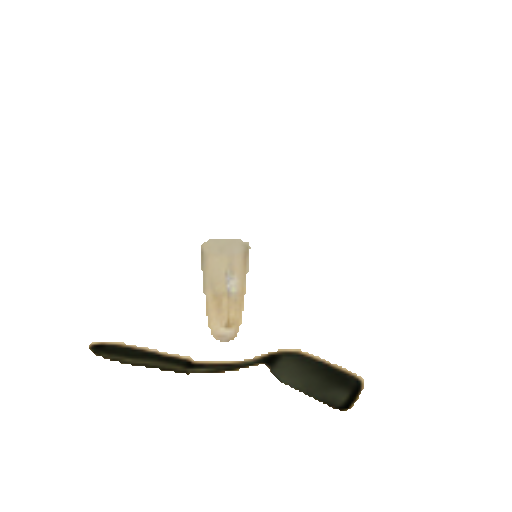

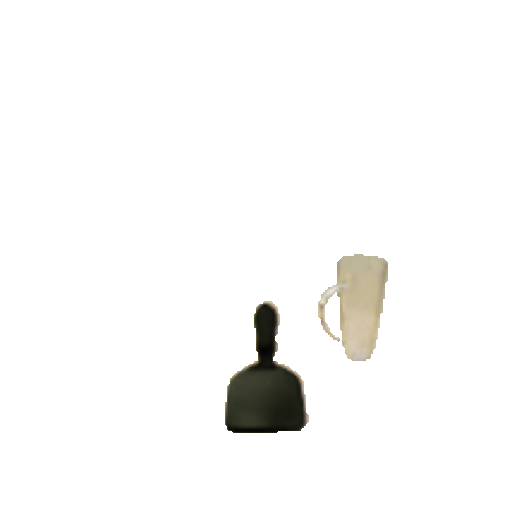

In [5]:
# resize & crop
X = torch.linspace(-tan_half_fov_zero123/tan_half_fov_x_realsense, tan_half_fov_zero123/tan_half_fov_x_realsense, H_zero123)
Y = torch.linspace(-tan_half_fov_zero123/tan_half_fov_y_realsense, tan_half_fov_zero123/tan_half_fov_y_realsense, W_zero123)
grid = torch.meshgrid(X, Y, indexing='xy')
grid = torch.stack([torch.stack(grid, dim=-1)]*len(rgbs))

cropped_normalized_rgb = torch.nn.functional.grid_sample(rgbs, grid)
cropped_rgb = (cropped_normalized_rgb * 255).type(torch.int)
cropped_mask = torch.nn.functional.grid_sample(instance_masks, grid)
cropped_mask = cropped_mask > 0.5 # these are mask_0.npy, mask_1.npy

foreground_mask = (cropped_mask.sum(dim=1) > 0.5).unsqueeze(1)
for img_idx, (rgb, foreground, mask) in enumerate(zip(cropped_rgb, foreground_mask, cropped_mask)):
    rgba = torch.cat((rgb, foreground*255), dim=0).permute(1, 2, 0).numpy().astype(np.uint8)
    display(Image.fromarray(rgba, 'RGBA')) # these are rgba_0.png, rgba_1.png

Since we use only the prompts from the first mask image, `prompts.txt` only needs to list the prompts in the order of the indices in the first mask image.

In [6]:
with open(os.path.join(data_path, "prompts.txt"), "r") as f:
    prompts = f.read()
print(prompts)

['Mug', 'spatula']
